In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [10]:
df = pd.read_csv("titanic_toy.csv")
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [12]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [16]:
x_train,x_test,y_train,y_test= train_test_split(df.drop(columns=["Survived"]),df["Survived"],test_size=0.2,random_state=42)

In [17]:
mean_age= x_train["Age"].mean()
median_age= x_train["Age"].median()

mean_fare= x_train["Fare"].mean()
median_fare= x_train["Fare"].median()

In [19]:
x_train["age_median"]=x_train["Age"].fillna(median_age)
x_train["age_mean"]=x_train["Age"].fillna(mean_age)

x_train["fare_median"]=x_train["Fare"].fillna(median_fare)
x_train["fare_mean"]=x_train["Fare"].fillna(mean_fare)
x_train

,Age,Fare,Family,age_median,age_mean,fare_median,fare_mean
331,45.5,28.5000,0,45.5,45.500000,28.5000,28.500000
733,23.0,13.0000,0,23.0,23.000000,13.0000,13.000000
382,32.0,7.9250,0,32.0,32.000000,7.9250,7.925000
704,26.0,7.8542,1,26.0,26.000000,7.8542,7.854200
813,6.0,31.2750,6,6.0,6.000000,31.2750,31.275000
...,...,...,...,...,...,...,...
106,21.0,7.6500,0,21.0,21.000000,7.6500,7.650000
270,NaN,31.0000,0,28.0,29.498846,31.0000,31.000000
860,41.0,NaN,2,41.0,41.000000,14.4000,32.517788
435,14.0,120.0000,3,14.0,14.000000,120.0000,120.000000


In [22]:
print(f"the varrience of original age column is : {x_train["Age"].var()}")
print(f"the varrience of  age column when age imputed with mean : {x_train["age_mean"].var()}")
print(f"the varrience of  age column when imputed with median : {x_train["age_median"].var()}")


print()
print()
print()
print(f"the varrience of original fare column is : {x_train["Fare"].var()}")
print(f"the varrience of  fare column when imputed with mean : {x_train["fare_mean"].var()}")
print(f"the varrience of  fare column when imputed with median : {x_train["fare_median"].var()}")


the varrience of original age column is : 210.2517072477435
the varrience of  age column when age imputed with mean : 168.85193366872227
the varrience of  age column when imputed with median : 169.20731007048155



the varrience of original fare column is : 2761.0314349486343
the varrience of  fare column when imputed with mean : 2621.232374951235
the varrience of  fare column when imputed with median : 2637.012481677765


<Axes: ylabel='Density'>

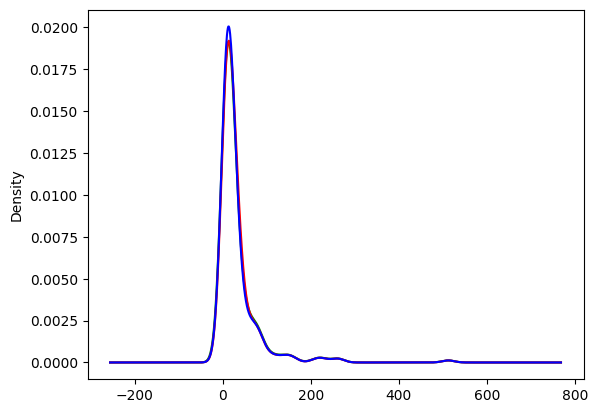

In [27]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train["Fare"].plot(kind="kde",ax=ax,color="green")

x_train["fare_mean"].plot(kind="kde",ax=ax,color="red")

x_train["fare_median"].plot(kind="kde", ax=ax, color="blue")



<Axes: ylabel='Density'>

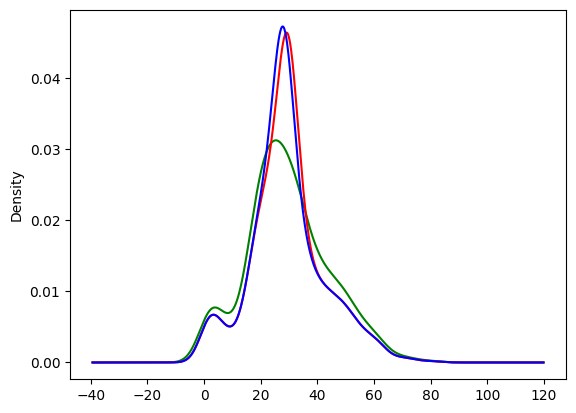

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)

x_train["Age"].plot(kind="kde",ax=ax,color="green")

x_train["age_mean"].plot(kind="kde",ax=ax,color="red")

x_train["age_median"].plot(kind="kde", ax=ax, color="blue")

In [30]:
x_train.cov()

,Age,Fare,Family,age_median,age_mean,fare_median,fare_mean
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,70.082085,71.193767
Fare,75.481375,2761.031435,18.599163,63.938058,60.224654,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.587710,-5.616299,17.672035,17.657433
age_median,210.251707,63.938058,-5.587710,169.207310,168.851934,59.728510,60.700688
age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,56.282518,57.175304
fare_median,70.082085,2761.031435,17.672035,59.728510,56.282518,2637.012482,2621.232375
fare_mean,71.193767,2761.031435,17.657433,60.700688,57.175304,2621.232375,2621.232375


<Axes: >

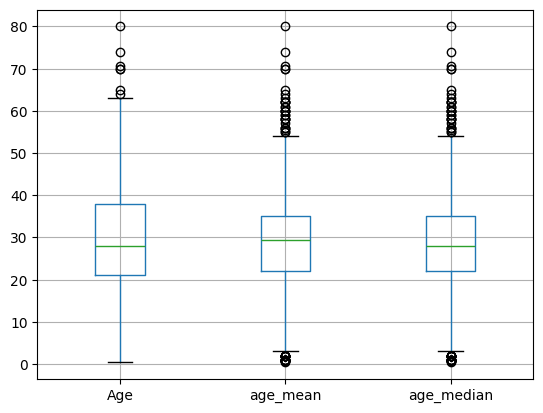

In [31]:
x_train[["Age","age_mean","age_median"]].boxplot()

In [32]:
x_train,x_test,y_train,y_test= train_test_split(df.drop(columns=["Survived"]),df["Survived"],test_size=0.2,random_state=42)

In [37]:
trf = ColumnTransformer([
    ("imputer1",SimpleImputer(strategy="median"),["Age"]),
    ("imputer2",SimpleImputer(strategy="mean"),["Fare"])
],remainder="passthrough")

In [38]:
trf.fit(x_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [42]:
trf.named_transformers_["imputer1"].statistics_, median_age

(array([28.]), np.float64(28.0))

# filling with random value

In [44]:
x_train["age_99"]=x_train["Age"].fillna(99)
x_train["age_minus1"]=x_train["Age"].fillna(-1)

x_train["fare_999"] = x_train["Fare"].fillna(999)
x_train["fare_minus1"] = x_train["Fare"].fillna(-1)
x_train

,Age,Fare,Family,age_99,age_minus1,fare_999,fare_minus1
331,45.5,28.5000,0,45.5,45.5,28.5000,28.5000
733,23.0,13.0000,0,23.0,23.0,13.0000,13.0000
382,32.0,7.9250,0,32.0,32.0,7.9250,7.9250
704,26.0,7.8542,1,26.0,26.0,7.8542,7.8542
813,6.0,31.2750,6,6.0,6.0,31.2750,31.2750
...,...,...,...,...,...,...,...
106,21.0,7.6500,0,21.0,21.0,7.6500,7.6500
270,NaN,31.0000,0,99.0,-1.0,31.0000,31.0000
860,41.0,NaN,2,41.0,41.0,999.0000,-1.0000
435,14.0,120.0000,3,14.0,14.0,120.0000,120.0000
